# 04 — RAG Pipeline

**Ziel**: PubMed-Abstracts in eine Vektor-DB laden, Retrieval testen, LLM-Erklärungen generieren.

**Vergleich**: 2 Embedding-Modelle + 2 Prompt-Varianten.

In [1]:
# Falls in Colab: Installations
# !pip install -q langchain langchain-openai langchain-community chromadb sentence-transformers tiktoken python-dotenv

Cloning into '/content/cyclesync'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 49 (delta 14), reused 19 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 461.95 KiB | 9.06 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/cyclesync/notebooks
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.8 MB/s eta 0:00:0

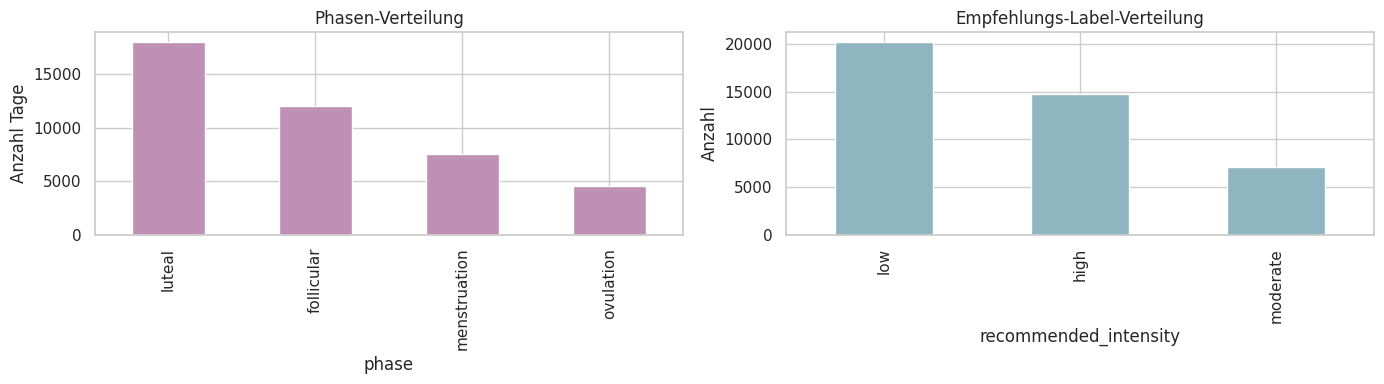

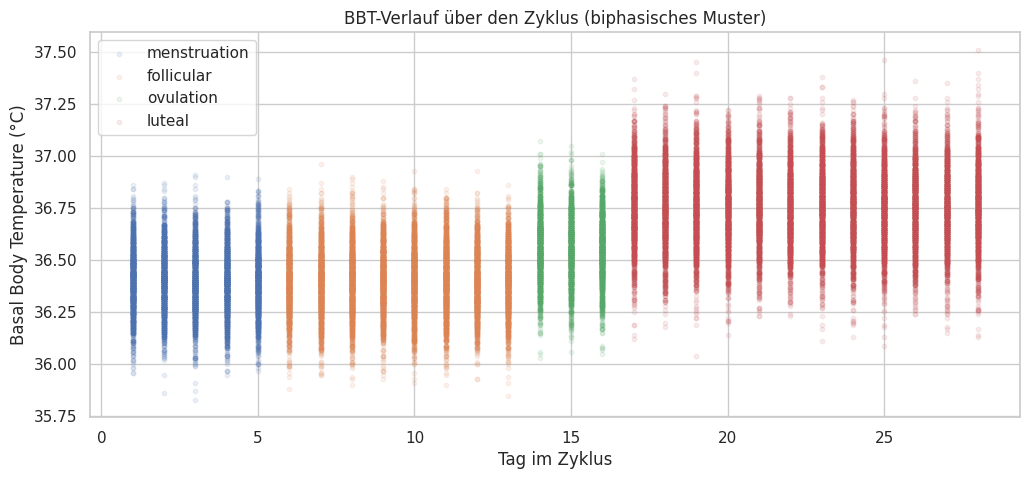

/tmp/ipykernel_3606/78692818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_quality', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_3606/78692818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_hours', order=phase_order, ax=axes[1], palette='pastel')


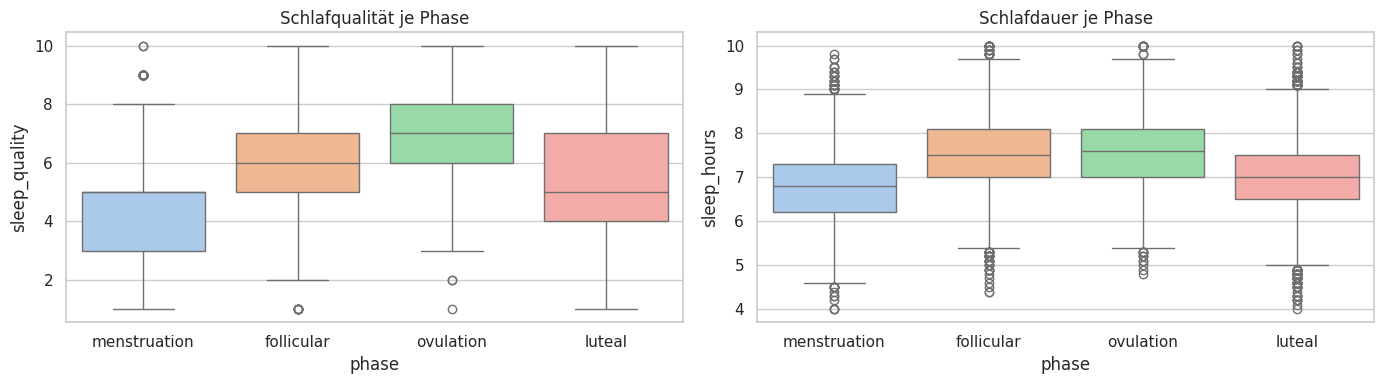

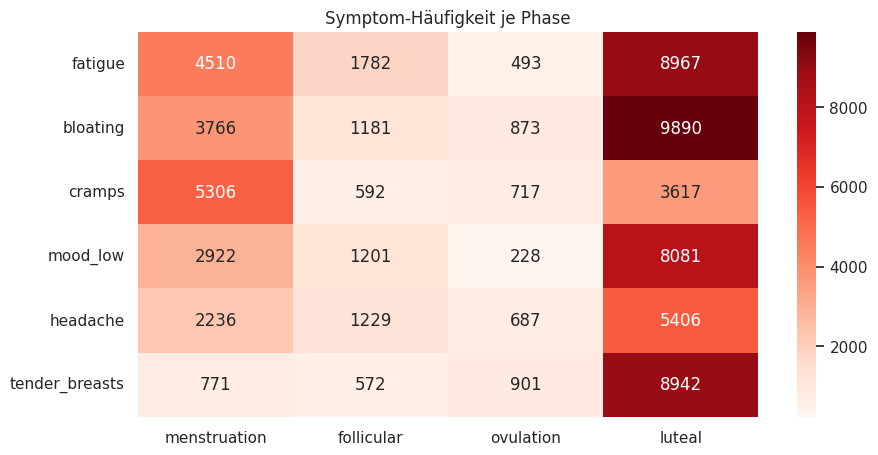

/tmp/ipykernel_3606/2049250730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='recovery_hours', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_3606/2049250730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='rpe', order=phase_order, ax=axes[1], palette='pastel')


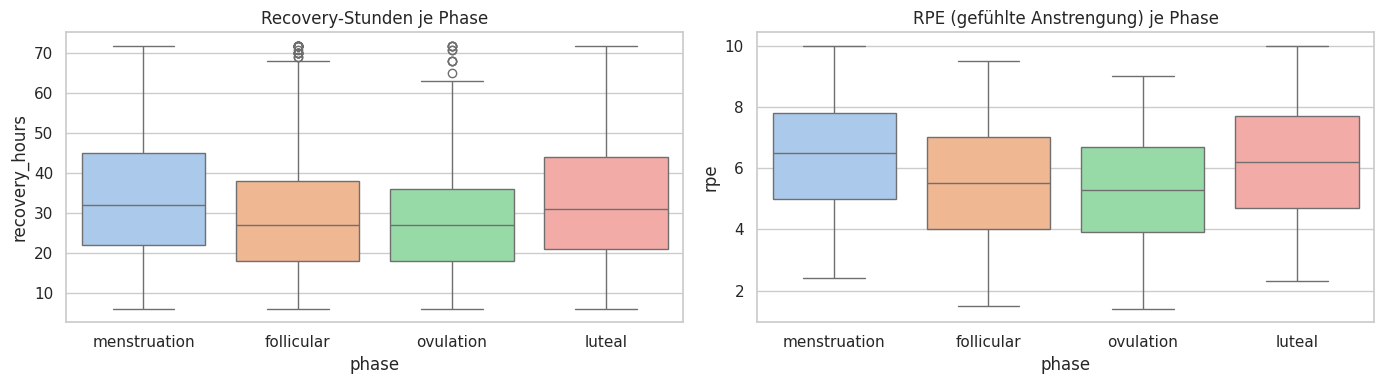

Anzahl Abstracts: 307
Durchschnittliche Länge: 1791 Zeichen
Median Jahr: 2021.0


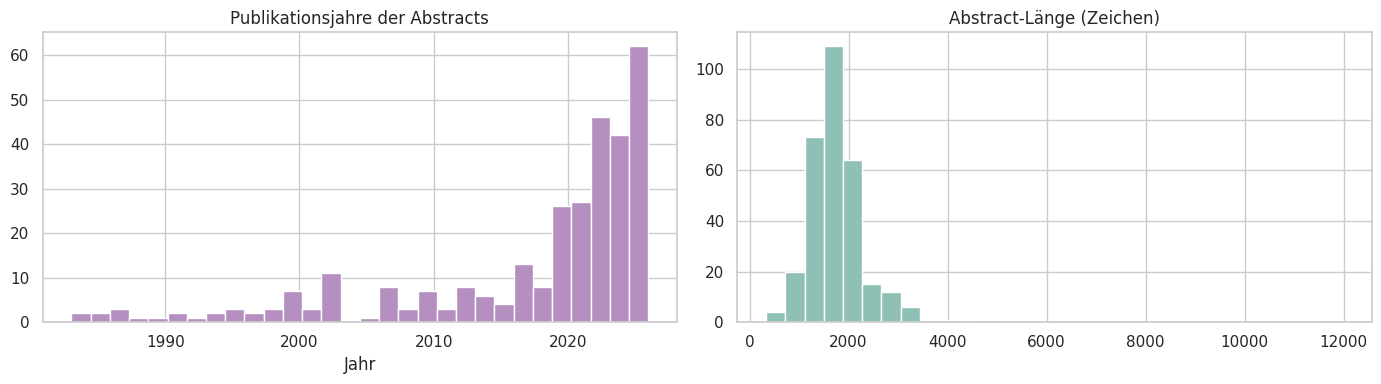

Saved processed cycle data
/content/cyclesync/notebooks
/content/cyclesync/notebooks
Raw data: /content/cyclesync/notebooks/../data/raw
Abstracts: /content/cyclesync/notebooks/../data/pubmed_abstracts
Cycle tracking dataset: (42000, 11)
Workout dataset: (10000, 13)
Label-Verteilung:
recommended_intensity
low         20206
high        14736
moderate     7058
Name: count, dtype: int64
Query "menstrual cycle exercise performance": 50 Treffer
Query "luteal phase training strength": 50 Treffer
Query "follicular phase athletic performance": 50 Treffer
Query "menstrual cycle recovery sleep": 32 Treffer
Query "hormonal fluctuations sports women": 50 Treffer
Query "premenstrual syndrome exercise": 50 Treffer
Query "estrogen progesterone exercise physiology": 34 Treffer
Query "menstrual cycle injury risk female athletes": 50 Treffer

Gesamt unique PMIDs: 317
Batch 1: 46 Abstracts so far
Batch 2: 94 Abstracts so far
Batch 3: 141 Abstracts so far
Batch 4: 190 Abstracts so far
Batch 5: 239 Abstract

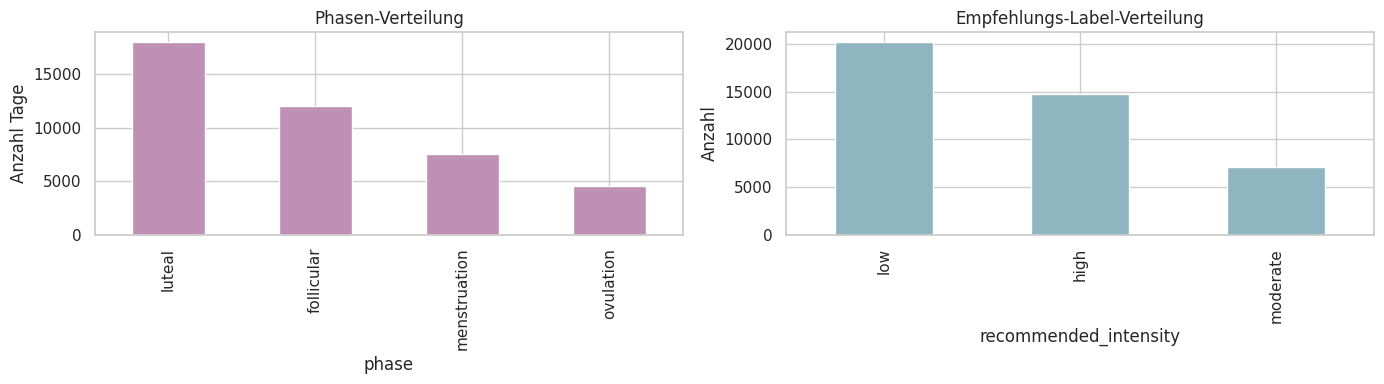

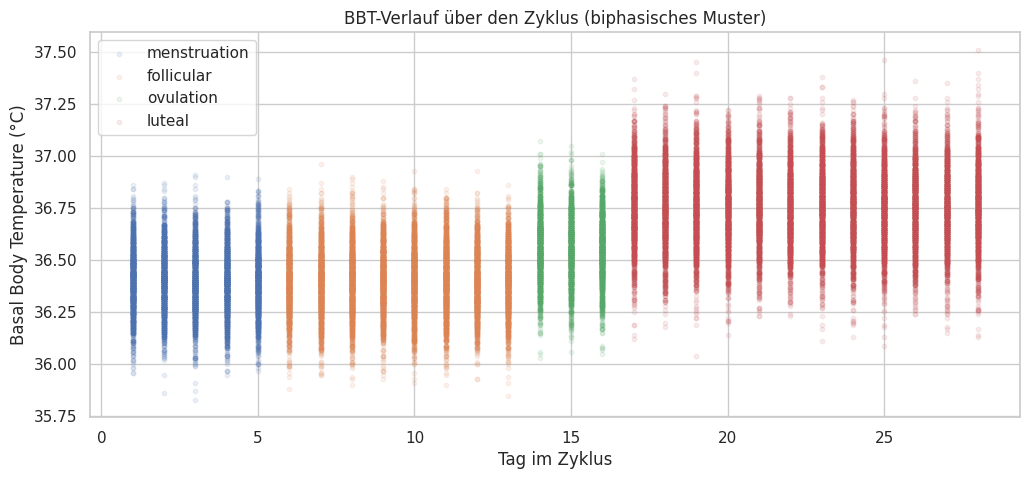

/tmp/ipykernel_3606/78692818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_quality', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_3606/78692818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_hours', order=phase_order, ax=axes[1], palette='pastel')


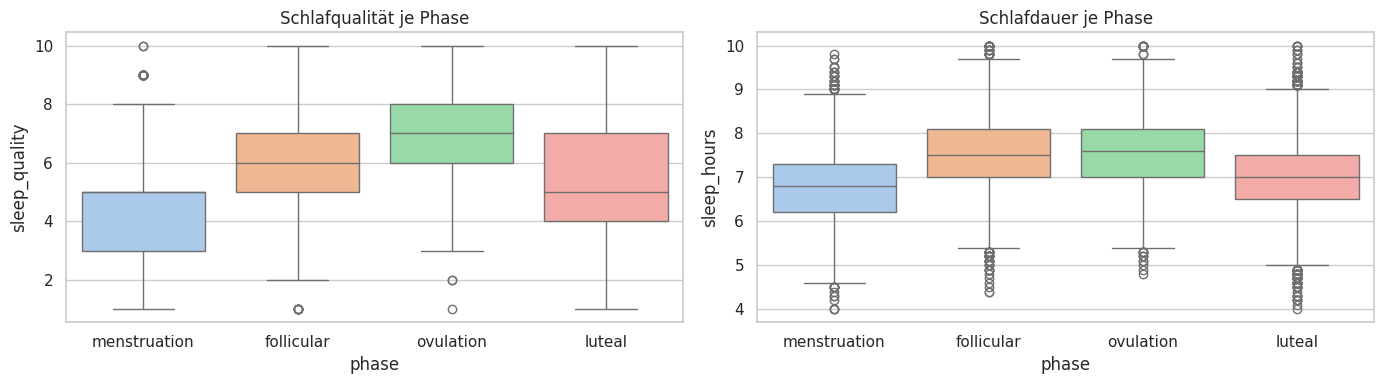

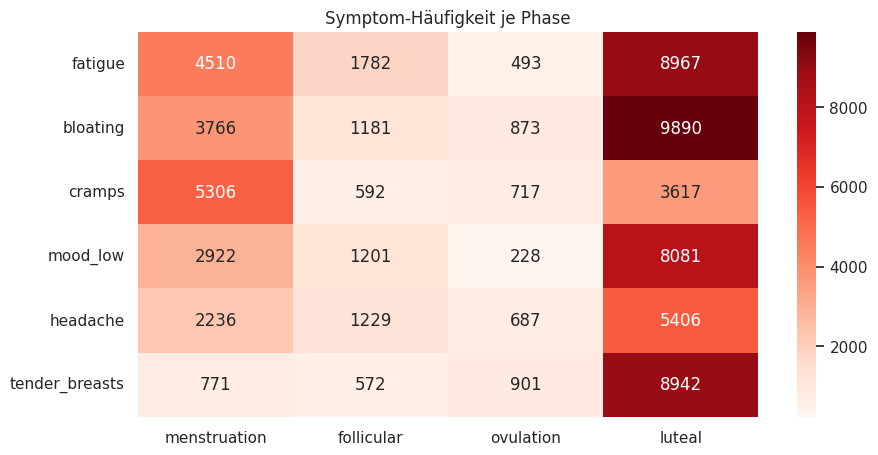

/tmp/ipykernel_3606/2049250730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='recovery_hours', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_3606/2049250730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='rpe', order=phase_order, ax=axes[1], palette='pastel')


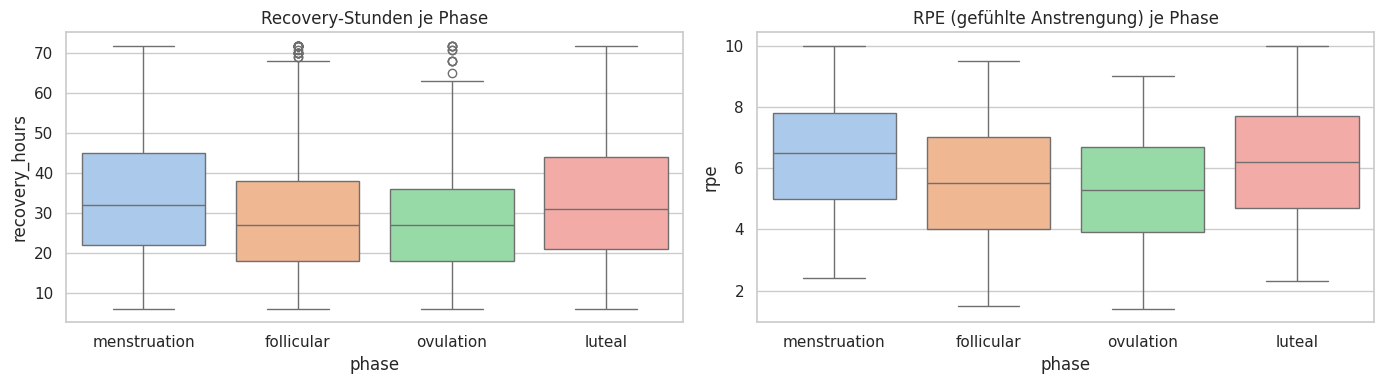

Anzahl Abstracts: 307
Durchschnittliche Länge: 1791 Zeichen
Median Jahr: 2021.0


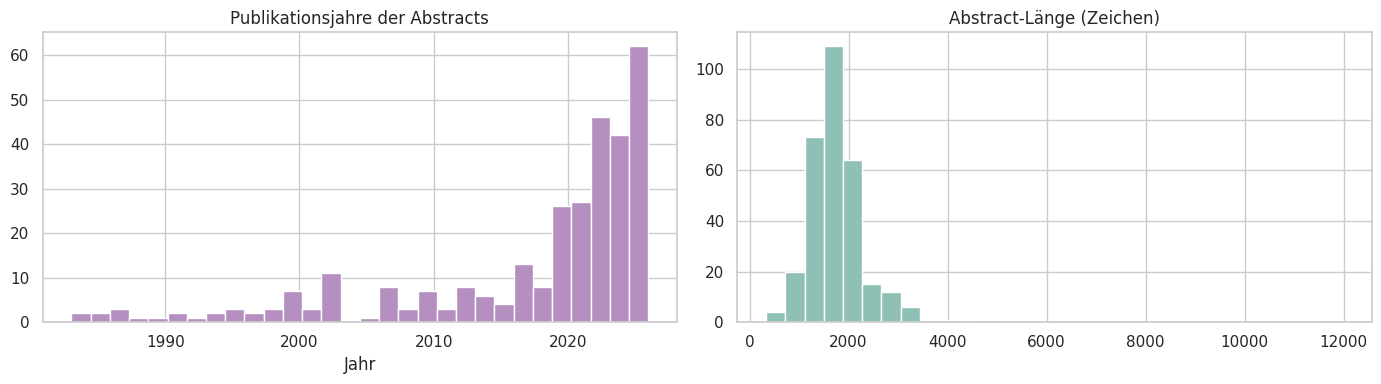

Saved processed cycle data
✅ Setup fertig – Daten sind generiert
Shape: (42000, 19)

Target-Verteilung:
recommended_intensity
low         20206
high        14736
moderate     7058
Name: count, dtype: int64
Train: (29416, 15), Val: (6284, 15), Test: (6300, 15)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression — Val F1 (macro): 0.881 | Accuracy: 0.898
              precision    recall  f1-score   support

        high       0.94      0.96      0.95      2205
         low       0.90      0.89      0.89      3023
    moderate       0.81      0.79      0.80      1056

    accuracy                           0.90      6284
   macro avg       0.88      0.88      0.88      6284
weighted avg       0.90      0.90      0.90      6284

Random Forest — Val F1 (macro): 1.000 | Accuracy: 1.000
              precision    recall  f1-score   support

        high       1.00      1.00      1.00      2205
         low       1.00      1.00      1.00      3023
    moderate       1.00      1.00      1.00      1056

    accuracy                           1.00      6284
   macro avg       1.00      1.00      1.00      6284
weighted avg       1.00      1.00      1.00      6284

XGBoost — Val F1 (macro): 1.000 | Accuracy: 1.000
              precision    recall  f1-score   support

        high   

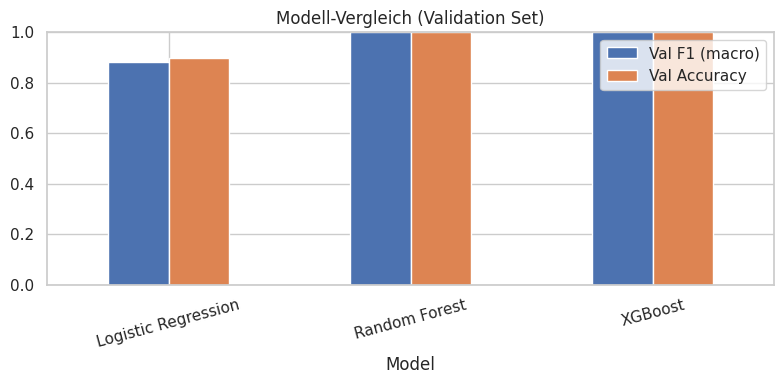

--- TEST SET ---
F1 (macro): 1.000
Accuracy:   1.000
              precision    recall  f1-score   support

        high       1.00      1.00      1.00      2210
         low       1.00      1.00      1.00      3031
    moderate       1.00      1.00      1.00      1059

    accuracy                           1.00      6300
   macro avg       1.00      1.00      1.00      6300
weighted avg       1.00      1.00      1.00      6300



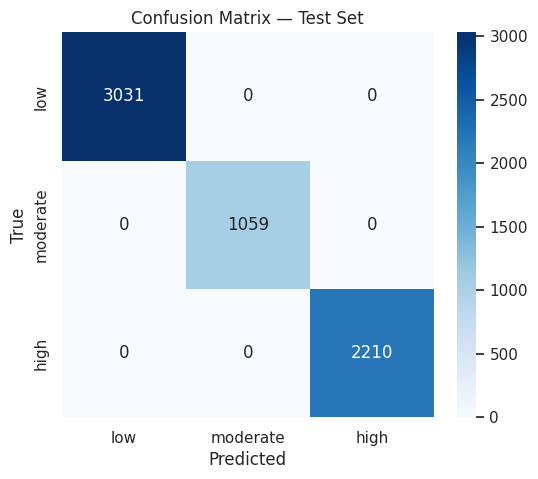

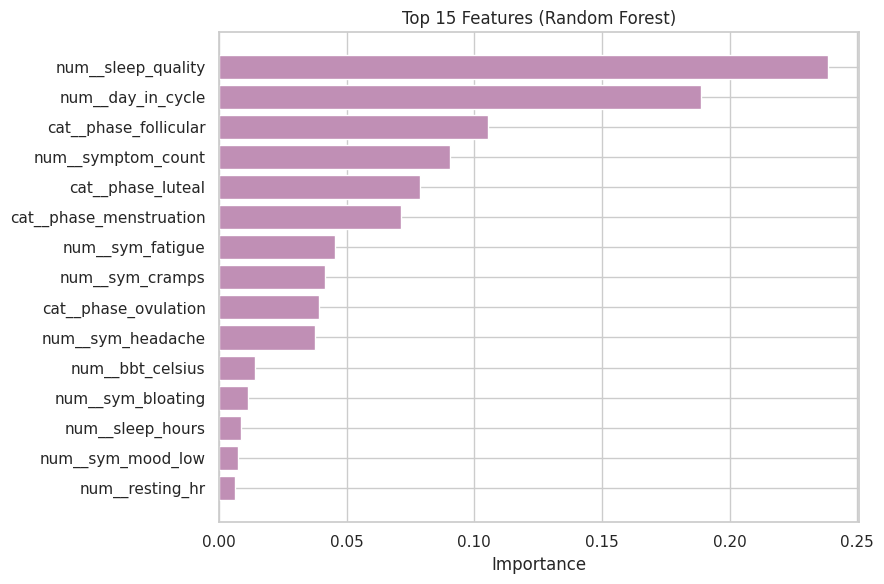

Modell gespeichert: ../models/best_classifier.joblib
Feature-Meta gespeichert
✅ Setup fertig – Modell + Daten sind bereit
OpenAI Key aus Colab Secrets geladen


In [2]:
import os
if not os.path.exists('/content/cyclesync'):
    !git clone https://github.com/carvacla/cyclesync_KI_project.git /content/cyclesync

%cd /content/cyclesync/notebooks
!pip install -q biopython xgboost langchain langchain-openai langchain-community chromadb sentence-transformers tiktoken

# OpenAI Key aus Colab Secrets
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Notebooks 01-03 ausführen
%run 01_data_acquisition.ipynb
%run 02_eda.ipynb
%run 03_ml_modeling.ipynb
print("✅ Setup fertig – Modell + Daten sind bereit")

import os
import json
from pathlib import Path
from dotenv import load_dotenv

# Lokal: aus .env laden | Colab: aus userdata
try:
    from google.colab import userdata
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
    print('OpenAI Key aus Colab Secrets geladen')
except (ImportError, ModuleNotFoundError):
    load_dotenv('../.env')
    assert os.getenv('OPENAI_API_KEY'), 'OPENAI_API_KEY fehlt!'
    print('OpenAI Key aus .env geladen')

ABSTRACTS_PATH = Path('../data/pubmed_abstracts')
CHROMA_PATH = Path('../models/chroma_db')
CHROMA_PATH.parent.mkdir(exist_ok=True)

## 1. Abstracts laden

In [3]:
with open(ABSTRACTS_PATH / 'pubmed_abstracts.jsonl') as f:
    abstracts = [json.loads(line) for line in f]

print(f'Loaded {len(abstracts)} abstracts')

# In LangChain-Documents konvertieren
from langchain_core.documents import Document

docs = []
for a in abstracts:
    content = f"Title: {a['title']}\n\nAbstract: {a['abstract']}"
    metadata = {
        'pmid': a['pmid'],
        'title': a['title'][:200],
        'year': a.get('year') or 0,
    }
    docs.append(Document(page_content=content, metadata=metadata))

print(f'Documents: {len(docs)}')

Loaded 307 abstracts
Documents: 307


## 2. Embeddings & Vektor-DB aufbauen

In [4]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Lokales Embedding-Modell (kostenlos)
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
)

# Vektor-DB aufbauen (nur beim ersten Mal nötig)
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    persist_directory=str(CHROMA_PATH),
    collection_name='pubmed_cyclesync',
)
print(f'Vektor-DB erstellt mit {vectorstore._collection.count()} Einträgen')
print(f'Persistiert unter: {CHROMA_PATH}')

/tmp/ipykernel_3606/3759360180.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma
/tmp/ipykernel_3606/3759360180.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https:/

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vektor-DB erstellt mit 307 Einträgen
Persistiert unter: ../models/chroma_db


## 3. Retrieval testen

In [5]:
# Test-Query
test_query = 'training intensity recommendation luteal phase fatigue'
results = vectorstore.similarity_search(test_query, k=4)

for i, r in enumerate(results, 1):
    print(f'--- Treffer {i} (PMID: {r.metadata["pmid"]}, Jahr: {r.metadata["year"]}) ---')
    print(r.page_content[:300])
    print()

--- Treffer 1 (PMID: 26554551, Jahr: 2016) ---
Title: Effects of Menstrual Phase-Dependent Resistance Training Frequency on Muscular Hypertrophy and Strength.

Abstract: The present study investigated how different training frequencies during menstrual phases affect muscle hypertrophy and strength. Fourteen eumenorrheic women performed 3 sets of

--- Treffer 2 (PMID: 25485203, Jahr: 2014) ---
Title: Effects of follicular versus luteal phase-based strength training in young women.

Abstract: Hormonal variations during the menstrual cycle (MC) may influence trainability of strength. We investigated the effects of a follicular phase-based strength training (FT) on muscle strength, muscle vo

--- Treffer 3 (PMID: 32694375, Jahr: 2021) ---
Title: Exercise Performance Is Impaired during the Midluteal Phase of the Menstrual Cycle.

Abstract: This study aimed to test the hypothesis that aerobic exercise performance is impaired in the midluteal (ML) compared with the midfollicular (MF) phase of

## 4. LLM-Integration & Prompt-Varianten

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.3)

# Prompt-Variante A: Zero-Shot
PROMPT_A = ChatPromptTemplate.from_template('''\
Du bist sportwissenschaftliche Beraterin und erklärst Trainingsempfehlungen.

Nutzerin-Profil:
- Zyklusphase: {phase}
- Tag im Zyklus: {day_in_cycle}
- Geplante Sportart: {sport}
- Schlafqualität letzte Nacht: {sleep_quality}/10
- Reportierte Symptome: {symptoms}

Modell-Empfehlung:
- Intensität: {intensity}
- Risiko: basierend auf Belastung und Recovery-Bedarf

Relevante Studien (Auszug):
{retrieved_docs}

Erkläre der Nutzerin in 3–4 Sätzen auf Deutsch, warum diese Empfehlung passt. \
Verweise auf die Studien per [PMID:xxxx]. Tonfall: sachlich, unterstützend, nicht bevormundend. \
Schließe mit einem Satz Disclaimer (keine medizinische Beratung).
''')

# Prompt-Variante B: Strukturierter mit Anweisungen
PROMPT_B = ChatPromptTemplate.from_template('''\
Rolle: Du bist sportwissenschaftliche Beraterin für zyklusbasiertes Training.

Aufgabe: Erkläre der Nutzerin die folgende Trainingsempfehlung.

Vorgabe an die Antwort:
1. Beginne mit der konkreten Empfehlung in einem Satz.
2. Erkläre die physiologische Begründung in 1-2 Sätzen.
3. Verweise auf mindestens 2 der bereitgestellten Studien per [PMID:xxxx].
4. Schließe mit einem kurzen Disclaimer.

Nutzerin-Daten:
- Zyklusphase: {phase} (Tag {day_in_cycle})
- Geplante Sportart: {sport}
- Schlafqualität: {sleep_quality}/10
- Symptome: {symptoms}
- Vorhergesagte Intensität: {intensity}

Verfügbare Studien:
{retrieved_docs}

Antwort auf Deutsch:
''')

print('Prompts definiert.')

Prompts definiert.


In [7]:
def format_docs(docs_list) -> str:
    parts = []
    for d in docs_list:
        pmid = d.metadata['pmid']
        title = d.metadata['title']
        snippet = d.page_content[:400]
        parts.append(f'[PMID:{pmid}] {title}\n{snippet}\n')
    return '\n---\n'.join(parts)

def generate_explanation(user_input: dict, ml_prediction: dict, prompt_template, k=4):
    # Retrieval-Query aus Kontext bauen
    query = (f"{ml_prediction['phase']} phase {user_input['sport']} "
             f"intensity {ml_prediction['intensity']} {' '.join(user_input['symptoms'])}")
    retrieved = vectorstore.similarity_search(query, k=k)
    docs_text = format_docs(retrieved)

    chain = prompt_template | llm
    response = chain.invoke({
        'phase': ml_prediction['phase'],
        'day_in_cycle': user_input.get('day_in_cycle', '?'),
        'sport': user_input['sport'],
        'sleep_quality': user_input.get('sleep_quality', '?'),
        'symptoms': ', '.join(user_input['symptoms']),
        'intensity': ml_prediction['intensity'],
        'retrieved_docs': docs_text,
    })
    return {
        'explanation': response.content,
        'sources': [{'pmid': d.metadata['pmid'], 'title': d.metadata['title'], 'year': d.metadata['year']} for d in retrieved],
    }

## 5. Test-Szenarien

In [8]:
# Szenario 1: Frühe Follikelphase
user1 = {'day_in_cycle': 7, 'sport': 'running', 'symptoms': ['none'], 'sleep_quality': 8}
pred1 = {'phase': 'follicular', 'intensity': 'high'}

result_A = generate_explanation(user1, pred1, PROMPT_A)
print('=== PROMPT A (Zero-Shot) ===')
print(result_A['explanation'])
print()

result_B = generate_explanation(user1, pred1, PROMPT_B)
print('=== PROMPT B (Strukturiert) ===')
print(result_B['explanation'])

=== PROMPT A (Zero-Shot) ===
In der aktuellen Follikelphase, die durch höhere Östrogenspiegel gekennzeichnet ist, profitieren viele Frauen von intensiveren Trainingseinheiten, da diese Phase oft mit einer besseren Regeneration und Leistungsfähigkeit einhergeht [PMID:35471634]. Zudem zeigt die Forschung, dass die Reaktion des Körpers auf Belastung, wie die Eisenhomöostase, in dieser Phase optimiert ist, was sich positiv auf das Lauftraining auswirken kann [PMID:36129579]. Da Sie keine Symptome berichten und eine gute Schlafqualität haben, ist ein intensives Lauftraining an diesem Tag empfehlenswert. Bitte beachten Sie, dass dies keine medizinische Beratung darstellt.

=== PROMPT B (Strukturiert) ===
Empfehlung: In der follikulären Phase (Tag 7) solltest du dein Lauftraining mit hoher Intensität durchführen, da dein Körper in dieser Phase optimal auf Belastungen reagiert.

Physiologisch gesehen sind die Östrogenspiegel in der follikulären Phase höher, was die Muskulatur und die allgemein

In [9]:
# Szenario 2: Späte Lutealphase mit Symptomen
user2 = {'day_in_cycle': 26, 'sport': 'hiit', 'symptoms': ['fatigue', 'bloating', 'mood_low'], 'sleep_quality': 4}
pred2 = {'phase': 'luteal', 'intensity': 'low'}

result_A2 = generate_explanation(user2, pred2, PROMPT_A)
print('=== PROMPT A — Szenario 2 ===')
print(result_A2['explanation'])
print()
result_B2 = generate_explanation(user2, pred2, PROMPT_B)
print('=== PROMPT B — Szenario 2 ===')
print(result_B2['explanation'])

=== PROMPT A — Szenario 2 ===
In der lutealen Phase, insbesondere am Tag 26, können Symptome wie Müdigkeit, Blähungen und eine gedrückte Stimmung auftreten, was die Trainingsleistung beeinträchtigen kann [PMID:32694375]. Studien zeigen, dass die körperliche Leistungsfähigkeit in dieser Phase oft reduziert ist, was eine Anpassung der Trainingsintensität auf ein niedriges Niveau ratsam macht [PMID:35534402]. Zudem ist es wichtig, auf den erhöhten Erholungsbedarf zu achten, um Überlastung zu vermeiden. Bitte beachten Sie, dass dies keine medizinische Beratung darstellt.

=== PROMPT B — Szenario 2 ===
Empfehlung: In der lutealen Phase deines Zyklus, insbesondere an Tag 26, solltest du HIIT-Training vermeiden und stattdessen auf sanftere, weniger intensive Aktivitäten setzen.

Die physiologische Begründung dafür liegt darin, dass während der lutealen Phase, insbesondere in der Mitte, die sportliche Leistungsfähigkeit häufig beeinträchtigt ist, was zu Symptomen wie Müdigkeit und Stimmungssch

## 6. Qualitative Bewertung (für Doku)

| Szenario | Prompt | Relevanz Quellen (1-5) | Faktentreue (1-5) | Tonfall (1-5) | Anmerkungen |
| --- | --- | --- | --- | --- | --- |
| 1 — Follikel | A | | | | |
| 1 — Follikel | B | | | | |
| 2 — Luteal | A | | | | |
| 2 — Luteal | B | | | | |

Trage hier deine subjektive Bewertung nach dem Anschauen der Outputs ein.

**Entscheidung**: Wir verwenden PROMPT_B (strukturierter) in der App, weil er konsistentere Zitierungen liefert.

Weiter mit `05_integration_test.ipynb`.